**Titanic Survival Prediction Using Machine Learning**

A Machine Learning project developed using Python and Scikit-learn to predict passenger survival based on Titanic dataset features.

In [2]:
#UPLOADING DATASET
import pandas as pd
df = pd.read_csv("/Titanic-Dataset.csv")

In [3]:
#DISPLAYING THE DATASET
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#DISPLAYING INFORMATION ABOUT THE DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#IDENTIFYING THE MISSING VALUE
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
#FILLING MISSING VALUE
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)

In [7]:
#VERIFING MISSING VALUE
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
#CONVERTING TEXT DATA INTO NUMERIC DATA
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [9]:
#CHECKING DATASET
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


In [10]:
#REMOVING UNNECESSARY COLUMNS
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [11]:
#AGAIN CHECKING DATASET
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [12]:
#DEFINING FEATURES AND TARGET
X = df.drop('Survived', axis=1)
y = df['Survived']

In [13]:
#SPPLITING DATASET
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
#TRAINING ML MODEL USING LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
#PREDICTING OUTPUT
y_pred = model.predict(X_test)

In [16]:
#FINDING ACCURACY
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [17]:
#TRAINING ML MODEL USING DESION TREE
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [18]:
#PREDICTING OUTPUT
dt_pred = dt.predict(X_test)

In [19]:
#FINDING ACCURACY
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.770949720670391


In [20]:
#TRAINING ML MODEL USING RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [21]:
#PREDICTING OUTPUT
rf_pred = rf.predict(X_test)

In [22]:
#FINDING ACCURACY
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8156424581005587


In [23]:
# CROSS VALIDATION
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross-Validation Accuracy:", cv_scores.mean().round(4))
print("Standard Deviation:", cv_scores.std().round(4))

Cross-Validation Accuracy: 0.7978
Standard Deviation: 0.0246


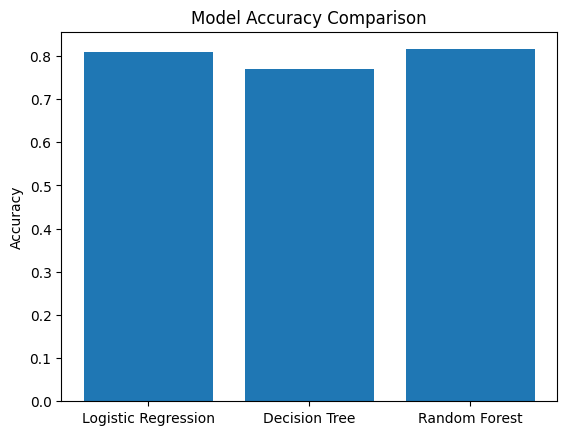

In [26]:
import matplotlib.pyplot as plt
#COMPARING MODEL ACCURACIES
models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']
accuracies = [accuracy,
              accuracy_score(y_test, dt_pred),
              accuracy_score(y_test, rf_pred)]
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [27]:
#CREATING CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [19 55]]


In [28]:
#CREATING CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



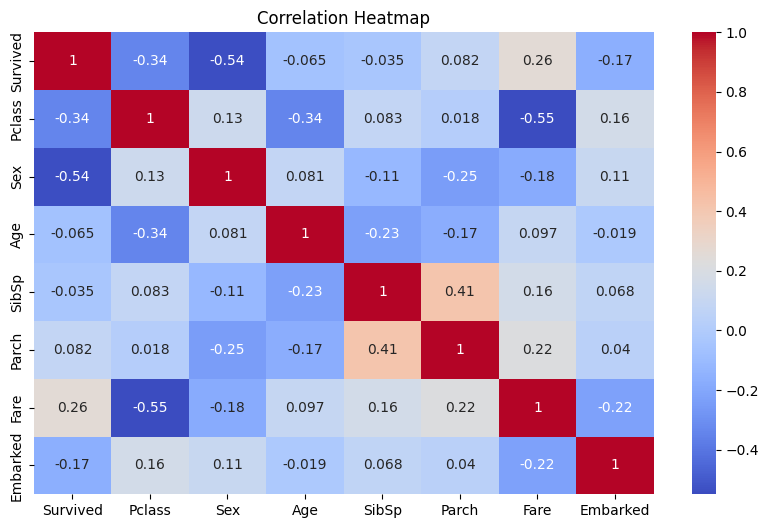

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
#CREATING CORRELATION HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

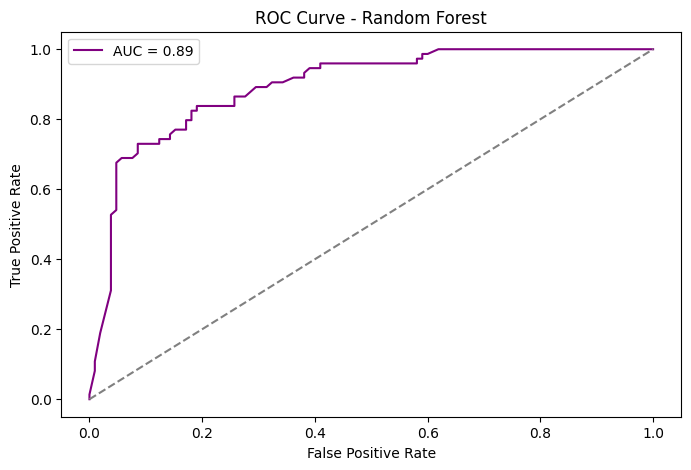

In [31]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='purple', label=f'AUC = {auc(fpr,tpr):.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

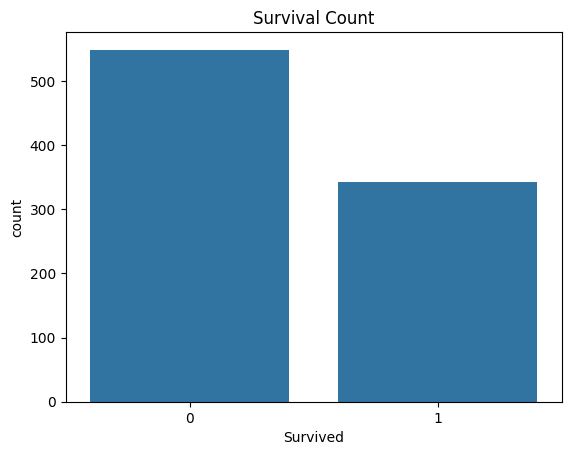

In [33]:
#CREATING VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

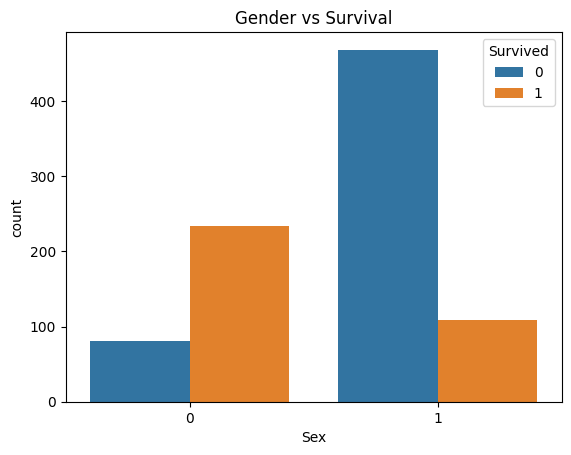

In [34]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

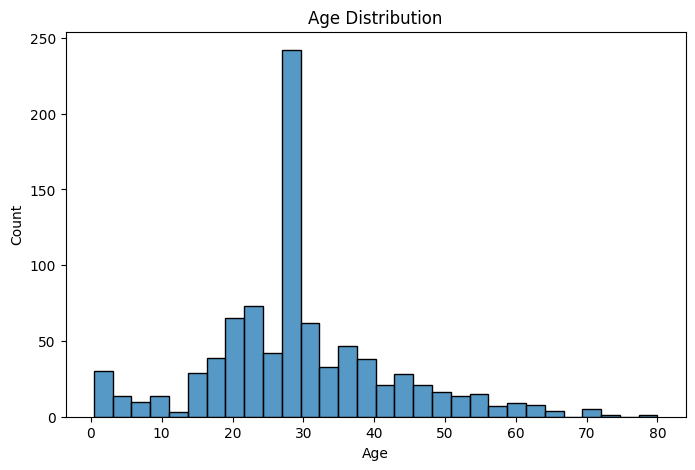

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

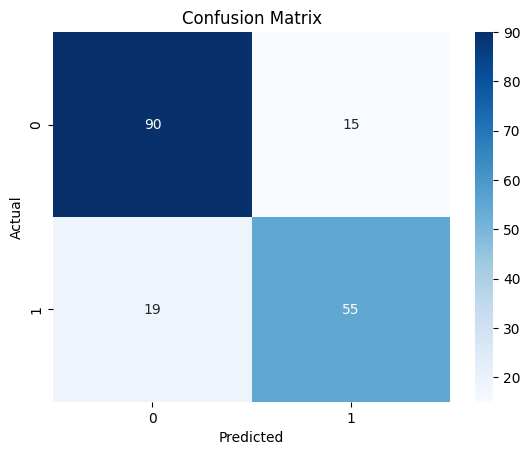

In [36]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()